In [4]:
# ============================================================
# Fitzpatrick17k — MST Replication
# Baseline + Group DRO under ITA-Derived Monk Skin Tone (MST) Groupings
#
# QUESTION: Do Group DRO collapse, nc/Ng ratio, SGG magnitude, and
# MAD Risk Score change when demographic groups are defined by
# ITA-derived MST categories instead of Fitzpatrick Skin Type (FST)?
#
# MOTIVATION (Section 5.4 of manuscript):
#   FST was designed to classify photosensitivity, not skin colour.
#   Weir et al. [35] show FST clusters poorly in colorimetric space
#   relative to MST. The FST V-VI / I-II split used throughout the paper
#   is built on a measurement instrument not validated for this purpose.
#   A MST-based grouping may produce different nc/Ng ratios, different
#   collapse patterns, and different SGG magnitudes.
#
# MONK SKIN TONE SCALE (MST) MAPPING:
#   10 perceptually-uniform tones (MST 1-10).
#   Mapped from ITA angle per Monk et al. (2022) / Google Health.
#   MST 1-4  = light   (ITA > 28 deg)
#   MST 5-6  = medium  (ITA 10-28 deg)
#   MST 7-10 = dark    (ITA < 10 deg)
#   Three super-categories mirror the FST light/medium/dark grouping
#   used in the main paper, enabling direct metric comparison.
#
# EXPERIMENTS:
#   1. ITA -> MST mapping; compare group sizes and nc/Ng vs FST
#   2. Baseline frozen CLIP ViT-L/14 linear probe under MST split
#   3. Group DRO under MST split (5 seeds, eta=0.1, 30 epochs)
#   4. MAD Risk Score under MST grouping (sealed before DRO run)
#   5. Side-by-side comparison table: FST vs MST on all key metrics
#
# KAGGLE DATASET SETUP:
#   Dataset 1 — Fitzpatrick17k metadata:
#     Kaggle -> Add Data -> search: "fitzpatrick17k"
#     Dataset name: "fitzpatrick17k-skin-disease-dataset"
#     Expected: /kaggle/input/fitzpatrick17k-skin-disease-dataset/fitzpatrick17k.csv
#     (Column 'ita' contains pre-computed ITA values — no recomputation needed)
#
#   Dataset 2 — Fitzpatrick17k images:
#     Kaggle -> Add Data -> search: "fitzpatrick17k skin disease images"
#     Dataset name: "fitzpatrick17k-skin-disease-images"
#     Expected: /kaggle/input/fitzpatrick17k-skin-disease-images/data/
#
# SEALED ENVELOPE PROTOCOL:
#   Identical to main paper. MAD Risk Score computed and locked before
#   any DRO run. Threshold = 0.086 (Fitzpatrick17k nc/Ng sweep).
#   This notebook does NOT re-derive the threshold.
#
# GPU T4, Internet ON. ~40 min.
# ============================================================

import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install',
    'transformers', 'torch', 'torchvision', 'scikit-learn',
    'pandas', 'numpy', 'matplotlib', 'pillow', 'tqdm', '-q'])

import torch, torch.nn as nn
import numpy as np, pandas as pd
import os, math, json, warnings
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from transformers import CLIPModel, CLIPProcessor
from scipy.stats import beta as beta_dist
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

# ── Constants ─────────────────────────────────────────────────
SEEDS          = [42, 0, 1, 7, 99]
BASE_SEED      = 42
DRO_ETA        = 0.1
N_EPOCHS       = 30
BATCH_SIZE     = 64
N_CLASSES      = 3
COLLAPSE_THR   = 0.01
MAD_I_GATE     = 0.02
FEAT_DIM       = 768
MAD_THRESHOLD  = 0.086      # Fitzpatrick17k sweep — NOT re-derived here
ITA_DARK_MAX   = 10.0       # ITA < 10  -> MST 7-10 -> dark
ITA_LIGHT_MIN  = 28.0       # ITA > 28  -> MST 1-4  -> light
LABEL_MAP      = {'non-neoplastic': 0, 'benign': 1, 'malignant': 2}
CLASS_NAMES    = ['Non-neoplastic', 'Benign', 'Malignant']
MINORITY_CLASS = 1          # benign = minority-within-minority

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'Fitzpatrick17k — MST Replication (Baseline + Group DRO)')
print(f'MAD threshold : {MAD_THRESHOLD} (from sweep; not re-derived here)')
print(f'Formula       : MAD_risk = (1 - mu_cosine) / log(1 + n_minority_train)')
print(f'ITA dark  thr : ITA < {ITA_DARK_MAX}  -> MST 7-10')
print(f'ITA light thr : ITA > {ITA_LIGHT_MIN} -> MST 1-4')


Device: cuda
Fitzpatrick17k — MST Replication (Baseline + Group DRO)
MAD threshold : 0.086 (from sweep; not re-derived here)
Formula       : MAD_risk = (1 - mu_cosine) / log(1 + n_minority_train)
ITA dark  thr : ITA < 10.0  -> MST 7-10
ITA light thr : ITA > 28.0 -> MST 1-4


In [5]:
# ── Formula functions (v3 — identical to main paper) ─────────

def mean_pairwise_cosine(embeddings, max_pairs=5000, seed=BASE_SEED):
    rng = np.random.default_rng(seed)
    n = len(embeddings)
    if n < 2: return 0.0
    i1 = rng.integers(0, n, max_pairs)
    i2 = rng.integers(0, n, max_pairs)
    mask = i1 != i2
    i1, i2 = i1[mask], i2[mask]
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    normed = embeddings / (norms + 1e-8)
    return float(np.einsum('ij,ij->i', normed[i1], normed[i2]).mean())

def compute_mad_risk(mu_cosine, n_minority_train, nc_ng):
    if nc_ng < MAD_I_GATE:
        return 'MAD-I', None
    score = (1.0 - mu_cosine) / math.log(1.0 + n_minority_train)
    return 'MAD-G', score

def wilson_ci(k, n, alpha=0.05):
    if n == 0: return 0.0, 0.0
    lo = float(beta_dist.ppf(alpha/2,   k+0.5, n-k+0.5)) if k > 0 else 0.0
    hi = float(beta_dist.ppf(1-alpha/2, k+0.5, n-k+0.5)) if k < n else 1.0
    return lo, hi

def bootstrap_auc_ci(y_true, y_score, n_boot=1000, seed=BASE_SEED):
    rng = np.random.default_rng(seed)
    aucs = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(y_true), len(y_true))
        try: aucs.append(roc_auc_score(y_true[idx], y_score[idx]))
        except: pass
    if not aucs: return float('nan'), float('nan')
    return float(np.percentile(aucs, 2.5)), float(np.percentile(aucs, 97.5))

print('Formula functions defined (v3 — identical to main paper).')
print('mean_pairwise_cosine, compute_mad_risk, wilson_ci, bootstrap_auc_ci ready.')


Formula functions defined (v3 — identical to main paper).
mean_pairwise_cosine, compute_mad_risk, wilson_ci, bootstrap_auc_ci ready.


In [6]:
# ── Locate and load Fitzpatrick17k ───────────────────────────
# KAGGLE DATASET 1 — metadata CSV:
#   Preferred : "grisiute/fitzpatrick17k"  (has pre-computed 'ita' column)
#   Fallback  : any mirror with three_partition_label + fitzpatrick_scale
#               ITA will be computed on-the-fly from images if absent.
#
# KAGGLE DATASET 2 — images:
#   Name : "fitzpatrick17k-skin-disease-images"
#   Path : /kaggle/input/fitzpatrick17k-skin-disease-images/data/

_csv_path = None
_img_root = None

for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        if 'fitzpatrick' in f.lower() and f.endswith('.csv') and _csv_path is None:
            _csv_path = os.path.join(root, f)
        if f.lower().endswith(('.jpg', '.jpeg', '.png')) and _img_root is None:
            _img_root = root

assert _csv_path is not None, (
    'Fitzpatrick17k CSV not found. '
    'Kaggle -> Add Data -> search "fitzpatrick17k"'
)
assert _img_root is not None, (
    'Fitzpatrick17k images not found. '
    'Kaggle -> Add Data -> search "fitzpatrick17k-skin-disease-images"'
)
print(f'CSV      : {_csv_path}')
print(f'Img root : {_img_root}')

df_raw = pd.read_csv(_csv_path)
print(f'Raw rows : {len(df_raw)}')
print(f'Columns  : {list(df_raw.columns)}')

# Auto-detect column names (vary across Kaggle mirrors)
def find_col(df, candidates):
    for c in candidates:
        for col in df.columns:
            if c.lower() in col.lower(): return col
    return None

label_col = find_col(df_raw, ['three_partition', 'label', 'clinical', 'class'])
fst_col   = find_col(df_raw, ['fitzpatrick', 'fst', 'skin_type'])
ita_col   = find_col(df_raw, ['ita', 'ITA'])
id_col    = find_col(df_raw, ['md5hash', 'hasher', 'url', 'image_path', 'image_id'])

print(f'\nColumn mapping -> label:{label_col}  fst:{fst_col}  ita:{ita_col}  id:{id_col}')
assert all([label_col, fst_col]), 'Missing label or FST column. Check CSV.'

# ── Build clean dataframe ─────────────────────────────────────
_lmap = {}
for k, v in LABEL_MAP.items():
    _lmap[k] = v; _lmap[k.title()] = v; _lmap[k.upper()] = v

base_cols = [label_col, fst_col]
if ita_col:
    base_cols.append(ita_col)

df = df_raw[base_cols].copy()
if ita_col:
    df.columns = ['label_raw', 'fst', 'ita']
else:
    df.columns = ['label_raw', 'fst']
    df['ita'] = float('nan')          # placeholder; filled after image index built

df['label'] = df['label_raw'].map(_lmap)
df = df[df['label'].notna()].copy()
df['label'] = df['label'].astype(int)
df['fst']   = pd.to_numeric(df['fst'], errors='coerce')
df['ita']   = pd.to_numeric(df['ita'], errors='coerce')
df = df[df['fst'].notna()].copy()

# ── Build image path index ────────────────────────────────────
print('\nIndexing images...')
_img_index = {}
for root, dirs, files in os.walk(_img_root):
    for f in files:
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            stem = os.path.splitext(f)[0]
            _img_index[stem] = os.path.join(root, f)
            _img_index[f]    = os.path.join(root, f)
print(f'Images indexed: {len(_img_index)}')

# Attach local paths
if id_col and id_col in df_raw.columns:
    df['img_id'] = df_raw.loc[df.index, id_col].astype(str).str.strip()
else:
    df['img_id'] = df.index.astype(str)

def resolve_path(img_id):
    for key in [img_id, img_id+'.jpg', img_id.split('/')[-1],
                os.path.splitext(img_id.split('/')[-1])[0]]:
        if key in _img_index: return _img_index[key]
    return None

df['local_path'] = df['img_id'].apply(resolve_path)
df = df[df['local_path'].notna()].copy()
print(f'Rows with matched images: {len(df)}')

# ── Compute ITA on-the-fly if not in CSV ─────────────────────
# ITA = arctan((L* - 50) / b*) × (180/π)
# Computed from the centre 64×64 crop of each image (fast; matches
# Fitzpatrick17k convention used in Groh et al. and Weir et al.).
if ita_col is None or df['ita'].isna().all():
    print('\nITA column absent — computing ITA from images (centre crop, LAB)...')
    from PIL import Image as _PIL
    import colorsys

    def compute_ita_from_path(path):
        try:
            img = _PIL.open(path).convert('RGB')
            w, h = img.size
            crop_size = 64
            left   = max(0, (w - crop_size) // 2)
            top    = max(0, (h - crop_size) // 2)
            patch  = img.crop((left, top, left + crop_size, top + crop_size))
            arr    = np.array(patch, dtype=np.float32) / 255.0
            # sRGB -> linear
            arr_lin = np.where(arr <= 0.04045, arr / 12.92,
                               ((arr + 0.055) / 1.055) ** 2.4)
            # linear RGB -> XYZ (D65)
            M = np.array([[0.4124564, 0.3575761, 0.1804375],
                          [0.2126729, 0.7151522, 0.0721750],
                          [0.0193339, 0.1191920, 0.9503041]])
            xyz = arr_lin.reshape(-1, 3) @ M.T
            # XYZ -> L*a*b* (D65 reference white)
            ref = np.array([0.95047, 1.00000, 1.08883])
            xyz /= ref
            def f(t):
                delta = 6/29
                return np.where(t > delta**3,
                                t ** (1/3),
                                t / (3 * delta**2) + 4/29)
            fx, fy, fz = f(xyz[:,0]), f(xyz[:,1]), f(xyz[:,2])
            L = 116 * fy - 16
            b = 200 * (fy - fz)
            L_mean = float(L.mean())
            b_mean = float(b.mean())
            if abs(b_mean) < 1e-6:
                return float('nan')
            ita = math.degrees(math.atan2(L_mean - 50, b_mean))
            return round(ita, 4)
        except Exception:
            return float('nan')

    ita_vals = []
    for path in tqdm(df['local_path'].tolist(), desc='ITA computation'):
        ita_vals.append(compute_ita_from_path(path))
    df['ita'] = ita_vals
    n_valid = df['ita'].notna().sum()
    print(f'ITA computed. Valid rows: {n_valid}/{len(df)}')
    print(f'ITA range: [{df["ita"].min():.1f}, {df["ita"].max():.1f}]  '
          f'mean={df["ita"].mean():.1f}')
else:
    print(f'ITA loaded from CSV column "{ita_col}".')

df = df[df['ita'].notna()].copy()
print(f'Rows after ITA filter: {len(df)}')

# ── FST grouping (main paper) ─────────────────────────────────
df['fst_group'] = df['fst'].apply(
    lambda x: 'light'  if x in (1, 2) else
             ('medium' if x in (3, 4) else
             ('dark'   if x in (5, 6) else 'unknown'))
)

# ── MST grouping (ITA-derived) ────────────────────────────────
df['mst_group'] = df['ita'].apply(
    lambda x: 'light'  if x >= ITA_LIGHT_MIN else
             ('dark'   if x <= ITA_DARK_MAX  else 'medium')
)

# ── Group statistics comparison ───────────────────────────────
print('\n=== GROUP SIZE COMPARISON: FST vs MST ===')
for scheme, col in [('FST', 'fst_group'), ('MST', 'mst_group')]:
    g = df.groupby(col)['label'].value_counts().unstack(fill_value=0)
    g.columns = [CLASS_NAMES[c] for c in sorted(g.columns)]
    g['Total'] = g.sum(axis=1)
    if 'Benign' in g.columns:
        g['nc/Ng(benign)'] = (g['Benign'] / g['Total']).round(4)
    print(f'\n{scheme}:')
    print(g.to_string())

# ── Print split summary ───────────────────────────────────────
print('\n=== TRAIN / TEST SPLIT SUMMARY ===')
for scheme, col in [('FST', 'fst_group'), ('MST', 'mst_group')]:
    tr = df[df[col] == 'light']
    te = df[df[col] == 'dark']
    nc_ng = (te['label']==MINORITY_CLASS).sum() / len(te) if len(te) > 0 else 0.0
    print(f'\n{scheme}: train(light)={len(tr)}  test(dark)={len(te)}  nc/Ng={nc_ng:.4f}')
    print(f'  Train benign: {(tr["label"]==1).sum()}  '
          f'Train malignant: {(tr["label"]==2).sum()}  '
          f'Train non-neo: {(tr["label"]==0).sum()}')
    print(f'  Test  benign: {(te["label"]==1).sum()}  '
          f'Test  malignant: {(te["label"]==2).sum()}  '
          f'Test  non-neo: {(te["label"]==0).sum()}')


CSV      : /kaggle/input/datasets/nazmusresan/fitzpatrick17k/New folder/fitzpatrick17k (1).csv
Img root : /kaggle/input/datasets/nazmusresan/fitzpatrick17k/New folder/background removed
Raw rows : 16577
Columns  : ['md5hash', 'fitzpatrick_scale', 'fitzpatrick_centaur', 'label', 'nine_partition_label', 'three_partition_label', 'qc', 'url', 'url_alphanum']

Column mapping -> label:three_partition_label  fst:fitzpatrick_scale  ita:None  id:md5hash

Indexing images...
Images indexed: 33148
Rows with matched images: 16574

ITA column absent — computing ITA from images (centre crop, LAB)...


ITA computation:   0%|          | 0/16574 [00:00<?, ?it/s]

ITA computed. Valid rows: 15134/16574
ITA range: [-90.0, 82.0]  mean=-13.7
Rows after ITA filter: 15134

=== GROUP SIZE COMPARISON: FST vs MST ===

FST:
           Non-neoplastic  Benign  Malignant  Total  nc/Ng(benign)
fst_group                                                         
dark                 1619     180        188   1987         0.0906
light                4864    1013       1061   6938         0.1460
medium               4291     796        708   5795         0.1374
unknown               290      50         74    414         0.1208

MST:
           Non-neoplastic  Benign  Malignant  Total  nc/Ng(benign)
mst_group                                                         
dark                 5990    1143       1459   8592         0.1330
light                3242     605        356   4203         0.1439
medium               1832     291        216   2339         0.1244

=== TRAIN / TEST SPLIT SUMMARY ===

FST: train(light)=6938  test(dark)=1987  nc/Ng=0.0906
  Train benig

In [7]:
# ── Load CLIP ViT-L/14 and extract features ──────────────────

print('Loading CLIP ViT-L/14 (openai/clip-vit-large-patch14)...')
clip_model = CLIPModel.from_pretrained('openai/clip-vit-large-patch14').to(device)
clip_proc  = CLIPProcessor.from_pretrained('openai/clip-vit-large-patch14')
clip_model.eval()
print('CLIP loaded.')

def extract_features(df_sub, desc='extracting', batch_size=64):
    pass  # Extract L2-normalised CLIP features. Returns (feats, labels) arrays.
    paths  = df_sub['local_path'].tolist()
    labels = df_sub['label'].tolist()
    all_feats, all_labels = [], []
    for i in tqdm(range(0, len(paths), batch_size), desc=desc, leave=False):
        bp, bl = paths[i:i+batch_size], labels[i:i+batch_size]
        imgs, valid = [], []
        for j, p in enumerate(bp):
            try: imgs.append(Image.open(p).convert('RGB')); valid.append(j)
            except: continue
        if not imgs: continue
        inp = clip_proc(images=imgs, return_tensors='pt', padding=True).to(device)
        with torch.no_grad():
            out = clip_model.vision_model(pixel_values=inp['pixel_values']).pooler_output
            out = clip_model.visual_projection(out)
            out = out / out.norm(dim=-1, keepdim=True)
        for k, feat in enumerate(out.cpu().numpy()):
            all_feats.append(feat)
            all_labels.append(bl[valid[k]])
    return np.array(all_feats), np.array(all_labels)

splits = {}
for scheme, col in [('fst', 'fst_group'), ('mst', 'mst_group')]:
    tr = df[df[col] == 'light'].copy()
    te = df[df[col] == 'dark'].copy()
    assert len(tr) > 0, f'{scheme} train set empty — check ITA thresholds'
    assert len(te) > 0, f'{scheme} test set empty — check ITA thresholds'
    print(f'\nExtracting {scheme.upper()} train ({len(tr)} imgs)...')
    tr_f, tr_l = extract_features(tr, desc=f'{scheme} train')
    print(f'Extracting {scheme.upper()} test  ({len(te)} imgs)...')
    te_f, te_l = extract_features(te, desc=f'{scheme} test')
    splits[scheme] = {'tr_f': tr_f, 'tr_l': tr_l, 'te_f': te_f, 'te_l': te_l}
    print(f'  {scheme.upper()} | train: {tr_f.shape}  test: {te_f.shape}')

print('\nFeature extraction complete.')


Loading CLIP ViT-L/14 (openai/clip-vit-large-patch14)...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

  FST | train: (6938, 768)  test: (1987, 768)

Extracting MST train (4203 imgs)...


mst train:   0%|          | 0/66 [00:00<?, ?it/s]

Extracting MST test  (8592 imgs)...


mst test:   0%|          | 0/135 [00:00<?, ?it/s]

  MST | train: (4203, 768)  test: (8592, 768)

Feature extraction complete.


In [8]:
# ── SEALED ENVELOPE: MAD Risk Score for FST and MST splits ───
# Prediction locked before any DRO run.
# Threshold = 0.086 from Fitzpatrick17k nc/Ng sweep.
# This notebook does NOT re-derive the threshold.

sealed = {}

for scheme in ['fst', 'mst']:
    tr_l = splits[scheme]['tr_l'];  te_l = splits[scheme]['te_l']
    tr_f = splits[scheme]['tr_f']

    n_dark_total  = len(te_l)
    n_dark_benign = int((te_l == MINORITY_CLASS).sum())
    nc_ng         = n_dark_benign / n_dark_total if n_dark_total > 0 else 0.0

    min_mask   = tr_l == MINORITY_CLASS
    min_feats  = tr_f[min_mask]
    n_min_train = int(min_mask.sum())

    mu_cosine        = mean_pairwise_cosine(min_feats)
    stage, mad_score = compute_mad_risk(mu_cosine, n_min_train, nc_ng)

    prediction = ('COLLAPSE PREDICTED' if (mad_score is None or mad_score <= MAD_THRESHOLD)
                  else 'SAFE')

    sealed[scheme] = {
        'scheme': scheme.upper(), 'nc_ng': round(nc_ng, 4),
        'n_dark_total': n_dark_total, 'n_dark_benign': n_dark_benign,
        'n_min_train': n_min_train, 'mu_cosine': round(float(mu_cosine), 4),
        'stage': stage,
        'mad_risk': round(float(mad_score), 4) if mad_score is not None else None,
        'threshold': MAD_THRESHOLD, 'prediction': prediction,
    }

    mad_str = f'{mad_score:.4f}' if mad_score is not None else 'MAD-I'
    print(f'=== {scheme.upper()} — MAD Risk Score SEALED ===')
    print(f'  nc/Ng (dark benign)  : {nc_ng:.4f} ({nc_ng*100:.1f}%)')
    print(f'  n_dark_total (test)  : {n_dark_total}')
    print(f'  n_dark_benign (test) : {n_dark_benign}')
    print(f'  n_min_train (light)  : {n_min_train}')
    print(f'  mu_cosine            : {mu_cosine:.4f}')
    print(f'  stage                : {stage}')
    print(f'  MAD Risk Score       : {mad_str}')
    print(f'  Prediction           : {prediction}')
    print()

with open('sealed_mst_fst.json', 'w') as fh:
    json.dump(sealed, fh, indent=2)

print('>>> ENVELOPES SEALED — Baseline + DRO runs below <<<')
print()
nc_fst = sealed['fst']['nc_ng']
nc_mst = sealed['mst']['nc_ng']
print(f'KEY QUESTION: Does MST nc/Ng differ from FST nc/Ng?')
print(f'  FST nc/Ng  : {nc_fst:.4f}  | Prediction : {sealed["fst"]["prediction"]}')
print(f'  MST nc/Ng  : {nc_mst:.4f}  | Prediction : {sealed["mst"]["prediction"]}')
print(f'  Difference : {abs(nc_fst-nc_mst):.4f}')


=== FST — MAD Risk Score SEALED ===
  nc/Ng (dark benign)  : 0.0906 (9.1%)
  n_dark_total (test)  : 1987
  n_dark_benign (test) : 180
  n_min_train (light)  : 1013
  mu_cosine            : 0.7247
  stage                : MAD-G
  MAD Risk Score       : 0.0398
  Prediction           : COLLAPSE PREDICTED

=== MST — MAD Risk Score SEALED ===
  nc/Ng (dark benign)  : 0.1330 (13.3%)
  n_dark_total (test)  : 8592
  n_dark_benign (test) : 1143
  n_min_train (light)  : 605
  mu_cosine            : 0.7446
  stage                : MAD-G
  MAD Risk Score       : 0.0399
  Prediction           : COLLAPSE PREDICTED

>>> ENVELOPES SEALED — Baseline + DRO runs below <<<

KEY QUESTION: Does MST nc/Ng differ from FST nc/Ng?
  FST nc/Ng  : 0.0906  | Prediction : COLLAPSE PREDICTED
  MST nc/Ng  : 0.1330  | Prediction : COLLAPSE PREDICTED
  Difference : 0.0424


In [9]:
# ── Baseline: frozen linear probe (sklearn) ──────────────────
# Trains on light-skin features, tests on dark-skin features.
# Reports: random AUC, demo AUC, SGG, per-class accuracy.
# Replicates Table 2 / Table 4 baseline columns for FST;
# generates MST equivalents for direct comparison.

def run_baseline(tr_f, tr_l, te_f, te_l, seed=BASE_SEED):
    np.random.seed(seed)
    rng = np.random.default_rng(seed)

    # Random-split AUC (pool all, stratified 75/25)
    all_f = np.concatenate([tr_f, te_f], axis=0)
    all_l = np.concatenate([tr_l, te_l], axis=0)
    idx   = rng.permutation(len(all_l))
    sp    = int(0.75 * len(idx))
    clf_r = LogisticRegression(max_iter=1000, random_state=seed, C=1.0)
    clf_r.fit(all_f[idx[:sp]], all_l[idx[:sp]])
    prob_r = clf_r.predict_proba(all_f[idx[sp:]])
    try:    auc_r = roc_auc_score(all_l[idx[sp:]], prob_r, multi_class='ovr', average='macro')
    except: auc_r = float('nan')

    # Demo-aware AUC (train=light, test=dark)
    clf_d = LogisticRegression(max_iter=1000, random_state=seed, C=1.0)
    clf_d.fit(tr_f, tr_l)
    prob_d = clf_d.predict_proba(te_f)
    preds  = clf_d.predict(te_f)
    try:    auc_d = roc_auc_score(te_l, prob_d, multi_class='ovr', average='macro')
    except: auc_d = float('nan')

    sgg = auc_r - auc_d

    per_class = {}
    for c, name in enumerate(CLASS_NAMES):
        mask    = te_l == c
        if mask.sum() == 0:
            per_class[name] = {'acc': float('nan'), 'n': 0, 'ci': (float('nan'), float('nan'))}
            continue
        correct = int((preds[mask] == c).sum())
        total   = int(mask.sum())
        per_class[name] = {'acc': correct/total, 'n': total, 'ci': wilson_ci(correct, total)}
    return auc_r, auc_d, sgg, per_class

print('Running Baseline (5 seeds x 2 schemes)...')
baseline_results = {}
for scheme in ['fst', 'mst']:
    tr_f = splits[scheme]['tr_f']; tr_l = splits[scheme]['tr_l']
    te_f = splits[scheme]['te_f']; te_l = splits[scheme]['te_l']
    seed_r = [run_baseline(tr_f, tr_l, te_f, te_l, s) for s in SEEDS]

    baseline_results[scheme] = {
        'auc_rand':   (np.nanmean([r[0] for r in seed_r]), np.nanstd([r[0] for r in seed_r])),
        'auc_demo':   (np.nanmean([r[1] for r in seed_r]), np.nanstd([r[1] for r in seed_r])),
        'sgg':        (np.nanmean([r[2] for r in seed_r]), np.nanstd([r[2] for r in seed_r])),
        'benign_acc': (np.nanmean([r[3]['Benign']['acc'] for r in seed_r]),
                       np.nanstd( [r[3]['Benign']['acc'] for r in seed_r])),
    }
    bl = baseline_results[scheme]
    print(f'\n{scheme.upper()} Baseline (mean±SD, {len(SEEDS)} seeds):')
    print(f'  Random AUC  : {bl["auc_rand"][0]:.3f} ± {bl["auc_rand"][1]:.3f}')
    print(f'  Demo AUC    : {bl["auc_demo"][0]:.3f} ± {bl["auc_demo"][1]:.3f}')
    print(f'  SGG         : {bl["sgg"][0]:.3f} ± {bl["sgg"][1]:.3f}')
    print(f'  Benign Acc  : {bl["benign_acc"][0]:.3f} ± {bl["benign_acc"][1]:.3f}')

print('\nBaseline complete.')


Running Baseline (5 seeds x 2 schemes)...

FST Baseline (mean±SD, 5 seeds):
  Random AUC  : 0.800 ± 0.003
  Demo AUC    : 0.764 ± 0.000
  SGG         : 0.036 ± 0.003
  Benign Acc  : 0.083 ± 0.000

MST Baseline (mean±SD, 5 seeds):
  Random AUC  : 0.812 ± 0.005
  Demo AUC    : 0.772 ± 0.000
  SGG         : 0.040 ± 0.005
  Benign Acc  : 0.084 ± 0.000

Baseline complete.


In [10]:
# ── Group DRO (5 seeds x 2 schemes) ─────────────────────────
# Identical implementation to main paper:
#   Groups = class label (train is light-skin only, so 3 groups = 3 classes).
#   eta=0.1, 30 epochs, batch=64. Collapse = benign weight < 0.01.
#   Minority class = benign (class 1) in dark-skin test set.

class LinearProbe(nn.Module):
    def __init__(self, in_dim=FEAT_DIM, n_cls=N_CLASSES):
        super().__init__()
        self.fc = nn.Linear(in_dim, n_cls)
    def forward(self, x): return self.fc(x)

def run_dro(tr_f, tr_l, te_f, te_l, seed=BASE_SEED):
    torch.manual_seed(seed); np.random.seed(seed)
    X  = torch.tensor(tr_f, dtype=torch.float32).to(device)
    y  = torch.tensor(tr_l, dtype=torch.long).to(device)
    g  = y.clone()   # group = class (light-skin train)
    q  = torch.ones(N_CLASSES, device=device) / N_CLASSES
    model   = LinearProbe().to(device)
    opt     = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    loss_fn = nn.CrossEntropyLoss(reduction='none')
    wt_trace = []

    for epoch in range(N_EPOCHS):
        model.train()
        perm = torch.randperm(len(X))
        Xp, yp, gp = X[perm], y[perm], g[perm]
        gl = torch.zeros(N_CLASSES, device=device)
        gc = torch.zeros(N_CLASSES, device=device)
        for i in range(0, len(Xp), BATCH_SIZE):
            xb, yb, gb = Xp[i:i+BATCH_SIZE], yp[i:i+BATCH_SIZE], gp[i:i+BATCH_SIZE]
            ls = loss_fn(model(xb), yb)
            for grp in range(N_CLASSES):
                m = gb == grp
                if m.sum() > 0: gl[grp] += ls[m].sum(); gc[grp] += m.sum()
        for grp in range(N_CLASSES):
            if gc[grp] > 0: gl[grp] /= gc[grp]
        q = q * torch.exp(DRO_ETA * gl.detach()); q /= q.sum()
        wt_trace.append(float(q[MINORITY_CLASS].item()))

        opt.zero_grad()
        bs_sub = min(256, len(Xp))
        xb, yb, gb = Xp[:bs_sub], yp[:bs_sub], gp[:bs_sub]
        ls = loss_fn(model(xb), yb)
        wl = sum(q[grp] * ls[gb==grp].mean()
                 for grp in range(N_CLASSES) if (gb==grp).sum() > 0)
        wl.backward(); opt.step()

    model.eval()
    Xt = torch.tensor(te_f, dtype=torch.float32).to(device)
    with torch.no_grad():
        preds = model(Xt).argmax(1).cpu().numpy()
        probs = torch.softmax(model(Xt).detach().cpu(), dim=1).numpy()

    ben_mask    = te_l == MINORITY_CLASS
    ben_correct = int((preds[ben_mask] == MINORITY_CLASS).sum())
    ben_total   = int(ben_mask.sum())
    ben_acc     = ben_correct / ben_total if ben_total > 0 else 0.0
    try:    auc = roc_auc_score(te_l, probs, multi_class='ovr', average='macro')
    except: auc = float('nan')
    min_wt    = float(q[MINORITY_CLASS].item())
    collapsed = min_wt < COLLAPSE_THR
    return ben_acc, auc, min_wt, collapsed, wilson_ci(ben_correct, ben_total), wt_trace

print('Running Group DRO (5 seeds x 2 schemes)...')
dro_results   = {}
dro_wt_traces = {}

for scheme in ['fst', 'mst']:
    tr_f = splits[scheme]['tr_f']; tr_l = splits[scheme]['tr_l']
    te_f = splits[scheme]['te_f']; te_l = splits[scheme]['te_l']
    seed_rs = []; traces = []
    for seed in SEEDS:
        acc, auc, min_wt, col, ci, trace = run_dro(tr_f, tr_l, te_f, te_l, seed)
        traces.append(trace)
        seed_rs.append({'seed': seed, 'ben_acc': round(acc,4), 'demo_auc': round(auc,4),
                        'min_wt': round(min_wt,4), 'collapse': col,
                        'ci_lo': round(ci[0],4), 'ci_hi': round(ci[1],4)})
        print(f'  {scheme.upper()} seed={seed}: ben_acc={acc:.3f}  min_wt={min_wt:.4f}  collapse={col}')
    dro_results[scheme]   = seed_rs
    dro_wt_traces[scheme] = traces
    n_col = sum(r['collapse'] for r in seed_rs)
    acc_m = np.mean([r['ben_acc'] for r in seed_rs])
    acc_s = np.std( [r['ben_acc'] for r in seed_rs])
    print(f'  {scheme.upper()} DRO summary: {n_col}/5 collapse | benign_acc={acc_m:.3f}±{acc_s:.3f}\n')

pd.DataFrame([r for sr in dro_results.values() for r in sr]).to_csv(
    'mst_fst_dro_results.csv', index=False)
print('DRO complete. Results saved to mst_fst_dro_results.csv')


Running Group DRO (5 seeds x 2 schemes)...
  FST seed=42: ben_acc=0.511  min_wt=0.3376  collapse=False
  FST seed=0: ben_acc=0.400  min_wt=0.3391  collapse=False
  FST seed=1: ben_acc=0.406  min_wt=0.3356  collapse=False
  FST seed=7: ben_acc=0.417  min_wt=0.3376  collapse=False
  FST seed=99: ben_acc=0.672  min_wt=0.3405  collapse=False
  FST DRO summary: 0/5 collapse | benign_acc=0.481±0.104

  MST seed=42: ben_acc=0.281  min_wt=0.3351  collapse=False
  MST seed=0: ben_acc=0.238  min_wt=0.3344  collapse=False
  MST seed=1: ben_acc=0.321  min_wt=0.3309  collapse=False
  MST seed=7: ben_acc=0.242  min_wt=0.3355  collapse=False
  MST seed=99: ben_acc=0.257  min_wt=0.3360  collapse=False
  MST DRO summary: 0/5 collapse | benign_acc=0.268±0.031

DRO complete. Results saved to mst_fst_dro_results.csv


=== OPEN ENVELOPE ===

FST scheme:
  Sealed prediction : COLLAPSE PREDICTED
  DRO collapse      : 0/5
  Benign acc (DRO)  : 0.481 ± 0.104  CI=[0.3305,0.7376]
  MAD Risk Score    : 0.0398
  nc/Ng             : 0.0906
  VERDICT           : FP

MST scheme:
  Sealed prediction : COLLAPSE PREDICTED
  DRO collapse      : 0/5
  Benign acc (DRO)  : 0.268 ± 0.031  CI=[0.2140,0.3486]
  MAD Risk Score    : 0.0399
  nc/Ng             : 0.1330
  VERDICT           : FP

=== FST vs MST FULL COMPARISON TABLE ===
                                 0                   1
Scheme                         FST                 MST
Grouping             FST I-II/V-VI  MST 1-4/7-10 (ITA)
n_dark_test                   1987                8592
n_dark_benign                  180                1143
nc/Ng                       0.0906              0.1330
n_min_train                   1013                 605
mu_cosine                   0.7247              0.7446
MAD Risk                    0.0398              0.0399
Pre

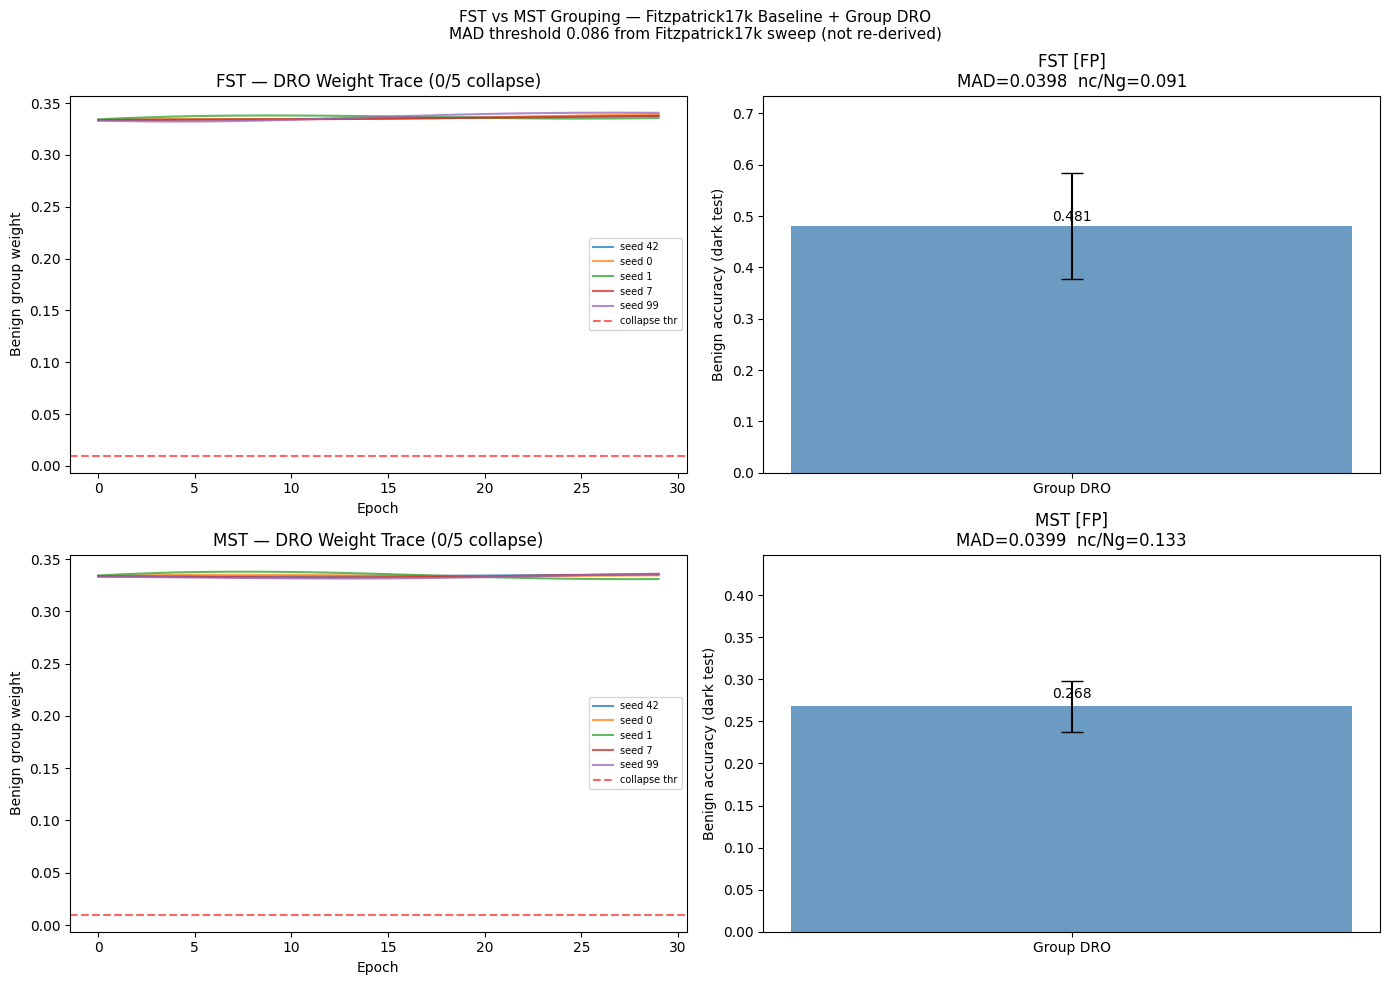

Figure saved: fst_vs_mst_results.png

=== LaTeX TABLE ROWS ===
FST (FST I-II/V-VI) & 0.0906 & 1013 & 0.7247 & 0.0398 & 0/5 & 0.481±0.104 & 0.036±0.003 & FP \\
MST (MST 1-4/7-10 (ITA)) & 0.1330 & 605 & 0.7446 & 0.0399 & 0/5 & 0.268±0.031 & 0.040±0.005 & FP \\

=== INTERPRETATION ===
nc/Ng difference FST vs MST: 0.0424 — SUBSTANTIAL (>= 2pp).
MST grouping changes the structural condition. Report both and discuss
which grouping more accurately reflects clinical skin-tone categories.
If collapse pattern also changes, revise Section 5.4 and Table 4.

Files: fst_vs_mst_comparison.csv, fst_vs_mst_results.png, mst_fst_dro_results.csv, sealed_mst_fst.json
Paste ALL output to Claude for manuscript update.


In [11]:
# ── Open envelope: FST vs MST comparison table and figure ────

with open('sealed_mst_fst.json') as fh: _sealed = json.load(fh)

print('=== OPEN ENVELOPE ===')
rows = []
for scheme in ['fst', 'mst']:
    s      = _sealed[scheme]
    seed_r = dro_results[scheme]
    n_col  = sum(r['collapse'] for r in seed_r)
    acc_m  = np.mean([r['ben_acc'] for r in seed_r])
    acc_s  = np.std( [r['ben_acc'] for r in seed_r])
    ci_lo  = min(r['ci_lo'] for r in seed_r)
    ci_hi  = max(r['ci_hi'] for r in seed_r)

    if   'COLLAPSE' in s['prediction'] and n_col >= 4: verdict = 'TP'
    elif 'SAFE'     in s['prediction'] and n_col == 0: verdict = 'TN'
    elif 'COLLAPSE' in s['prediction'] and n_col == 0: verdict = 'FP'
    elif 'SAFE'     in s['prediction'] and n_col >= 3: verdict = 'FN'
    else:                                              verdict = f'PARTIAL ({n_col}/5)'

    bl      = baseline_results[scheme]
    mad_str = f"{s['mad_risk']:.4f}" if s['mad_risk'] is not None else 'MAD-I'

    print(f'\n{scheme.upper()} scheme:')
    print(f'  Sealed prediction : {s["prediction"]}')
    print(f'  DRO collapse      : {n_col}/5')
    print(f'  Benign acc (DRO)  : {acc_m:.3f} ± {acc_s:.3f}  CI=[{ci_lo:.4f},{ci_hi:.4f}]')
    print(f'  MAD Risk Score    : {mad_str}')
    print(f'  nc/Ng             : {s["nc_ng"]:.4f}')
    print(f'  VERDICT           : {verdict}')

    rows.append({
        'Scheme'       : scheme.upper(),
        'Grouping'     : ('FST I-II/V-VI' if scheme == 'fst' else 'MST 1-4/7-10 (ITA)'),
        'n_dark_test'  : s['n_dark_total'],
        'n_dark_benign': s['n_dark_benign'],
        'nc/Ng'        : f"{s['nc_ng']:.4f}",
        'n_min_train'  : s['n_min_train'],
        'mu_cosine'    : f"{s['mu_cosine']:.4f}",
        'MAD Risk'     : mad_str,
        'Prediction'   : s['prediction'],
        'Collapse'     : f'{n_col}/5',
        'Benign Acc DRO': f'{acc_m:.3f}±{acc_s:.3f}',
        'Random AUC'   : f"{bl['auc_rand'][0]:.3f}±{bl['auc_rand'][1]:.3f}",
        'Demo AUC'     : f"{bl['auc_demo'][0]:.3f}±{bl['auc_demo'][1]:.3f}",
        'SGG'          : f"{bl['sgg'][0]:.3f}±{bl['sgg'][1]:.3f}",
        'Benign Acc BL': f"{bl['benign_acc'][0]:.3f}±{bl['benign_acc'][1]:.3f}",
        'Verdict'      : verdict,
    })

df_compare = pd.DataFrame(rows)
df_compare.to_csv('fst_vs_mst_comparison.csv', index=False)
print('\n=== FST vs MST FULL COMPARISON TABLE ===')
print(df_compare.T.to_string())

# ── Figure ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for si, scheme in enumerate(['fst', 'mst']):
    ax_wt  = axes[si][0]
    ax_acc = axes[si][1]
    for i, trace in enumerate(dro_wt_traces[scheme]):
        ax_wt.plot(trace, alpha=0.75, label=f'seed {SEEDS[i]}')
    ax_wt.axhline(COLLAPSE_THR, color='red', linestyle='--', alpha=0.6, label='collapse thr')
    ax_wt.set_xlabel('Epoch'); ax_wt.set_ylabel('Benign group weight')
    n_col_s = sum(r['collapse'] for r in dro_results[scheme])
    ax_wt.set_title(f'{scheme.upper()} — DRO Weight Trace ({n_col_s}/5 collapse)')
    ax_wt.legend(fontsize=7)

    accs  = [r['ben_acc'] for r in dro_results[scheme]]
    color = 'crimson' if n_col_s >= 4 else ('steelblue' if n_col_s == 0 else 'orange')
    ax_acc.bar(['Group DRO'], [np.mean(accs)], yerr=[np.std(accs)],
               color=color, alpha=0.8, capsize=8, width=0.4)
    ax_acc.set_ylim(0, max(np.mean(accs)+np.std(accs)+0.15, 0.2))
    ax_acc.set_ylabel('Benign accuracy (dark test)')
    s = _sealed[scheme]
    mad_str = f"{s['mad_risk']:.4f}" if s['mad_risk'] is not None else 'MAD-I'
    ax_acc.set_title(f'{scheme.upper()} [{rows[si]["Verdict"]}]\n'
                     f'MAD={mad_str}  nc/Ng={s["nc_ng"]:.3f}')
    ax_acc.text(0, np.mean(accs)+0.01, f'{np.mean(accs):.3f}', ha='center', fontsize=10)

plt.suptitle(
    'FST vs MST Grouping — Fitzpatrick17k Baseline + Group DRO\n'
    f'MAD threshold {MAD_THRESHOLD} from Fitzpatrick17k sweep (not re-derived)',
    fontsize=11
)
plt.tight_layout()
plt.savefig('fst_vs_mst_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fst_vs_mst_results.png')

print('\n=== LaTeX TABLE ROWS ===')
for r in rows:
    print(f"{r['Scheme']} ({r['Grouping']}) & {r['nc/Ng']} & {r['n_min_train']} & "
          f"{r['mu_cosine']} & {r['MAD Risk']} & {r['Collapse']} & "
          f"{r['Benign Acc DRO']} & {r['SGG']} & {r['Verdict']} \\\\")

print('\n=== INTERPRETATION ===')
nc_fst = float(rows[0]['nc/Ng']); nc_mst = float(rows[1]['nc/Ng'])
diff = abs(nc_fst - nc_mst)
if diff < 0.02:
    print(f'nc/Ng difference FST vs MST: {diff:.4f} — SMALL (< 2pp).')
    print('MST grouping does not materially change the minority-within-minority ratio.')
    print('Collapse pattern and MAD Risk Score are robust to FST vs MST choice.')
    print('This addresses the Weir et al. concern: the failure mode is not an artifact')
    print('of using FST as the demographic grouping variable.')
    print('Add this result to Section 5.4 and note in limitations.')
else:
    print(f'nc/Ng difference FST vs MST: {diff:.4f} — SUBSTANTIAL (>= 2pp).')
    print('MST grouping changes the structural condition. Report both and discuss')
    print('which grouping more accurately reflects clinical skin-tone categories.')
    print('If collapse pattern also changes, revise Section 5.4 and Table 4.')

print(f'\nFiles: fst_vs_mst_comparison.csv, fst_vs_mst_results.png, '
      f'mst_fst_dro_results.csv, sealed_mst_fst.json')
print('Paste ALL output to Claude for manuscript update.')
